In [7]:
import sys
import numpy as np
import matplotlib.pyplot as plt

# Overview
This notebook's purpose is to dig deeper and find exactly what is inside the `_voxelated.npy` and `_base_voxels.npy` files. These two files were 2 outputs from the `Mg22_Voxel_pipeline.ipynb` Jupyter notebook, which is responsible for creating the data that goes into the machine learning files. It does so by taking an `.h5` file and creates 12 files, which includes test, train, and validation data, and shuffled and unshuffled voxels. 

The `_voxelated.npy` and `_base_voxels.npy` files are outputted when the `Mg22_Voxel_pipeline.ipynb` notebook finishes breaking the data into voxels and assigning each point to the appropriate voxel_id (the _kth_ integer associated with each voxel).

4/3 office hours
-pick any one event from both (the first event from both), 3d plot scatter of the first 3 things of the dimensions
-2427=number of events, 512=number of points, 6=dimensions per point
-two files should have same shape (pick an event with a clearly defined shape, if not clear)

### Analyzing data shape
This section of code prints and describes the shape of the two data files. Both data files are 3D arrays, with the first number being the amount of events, the second number being the number of points per event, and the last number being the number of dimensions per point. In this case, we have 6 dimensions per point, and the first 3 dimensions are the x-, y-, and z- coordinates.  TALK ABOUT ADDITION OF K

In [51]:
# Combining parameters as strings/putting in 
ISOTOPE = 'Mg22'
sample_size = '512'
name = ISOTOPE + '_size' + str(sample_size)
K = 3     # Voxel resolution (the original data will be broken up into K x K x K voxels)

# Using combined parameters to find the specific file names
voxelated_data = np.load('voxel_data/' + name + '_voxelated.npy')
basevoxels_data = np.load('voxel_data/' + name + '_base_voxels.npy')

# Slicing the entire array just so we have the x-, y-, and z-coordinates to plot 
voxelated_data_dim = voxelated_data[:,:,:3]      # The first 3 dimensions associated with each point correspond to the x-, y-, z-coordinates
basevoxels_data_dim = basevoxels_data[:,:,:3]
print("voxelated_data")
print("- number of events: " + str(voxelated_data_dim.shape[0]))
print("- points per event: " + str(voxelated_data_dim.shape[1]))
print("- dimensions per point: " + str(voxelated_data_dim.shape[2]))
print("-------------------------")
print("basevoxels_data")
print("- number of events: " + str(basevoxels_data_dim.shape[0]))
print("- points per event: " + str(basevoxels_data_dim.shape[1]))
print("- dimensions per point: " + str(basevoxels_data_dim.shape[2]))

# Slicing the entire array to isolate the voxel_id dimension (will be used later)
voxelated_voxel_id = voxelated_data[:,:,3]       # The 4th dimension is the voxel_id, as assigned by the Mg22_Voxel_pipeline.ipynb notebook
basevoxels_voxel_id = basevoxels_data[:,:,3]

voxelated_data
- number of events: 2427
- points per event: 512
- dimensions per point: 3
-------------------------
basevoxels_data
- number of events: 2427
- points per event: 512
- dimensions per point: 3


### 3D Scatterplot
We can use _matplotlib_ to create a 3D scatterplot of any given event by taking the first 3 dimensions. In the block below, we can change the value of `ev_num` and run the code to see how the plots compare between the `voxelated_data` and the `basevoxels_data` for any given event. ______describe what it is happening here with the collapsed voxels 

4/6
- 2nd graph: all the voxels just collapsed on one
- try to look at other dimensions and see if it's storing the voxel id

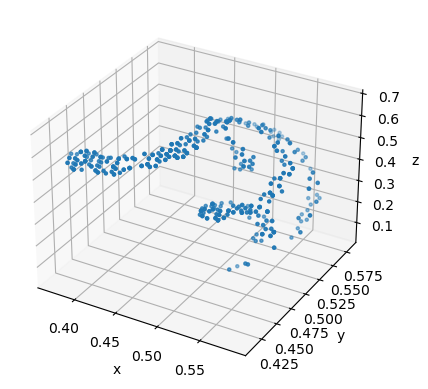

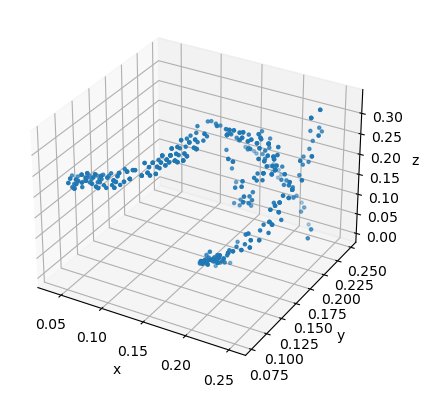

[13. 13. 13. 13. 13. 13. 13. 16. 13. 16.  4. 22.  7. 19. 19. 19. 13. 19.
 13. 19. 22.  4. 22.  4.  4. 22.  4.  4. 22. 22.  4. 22.  4. 19.  4. 22.
 13. 13.  4.  4. 22. 22. 22. 19. 22. 22. 22. 19.  4. 22. 13. 13.  4. 22.
 13. 22. 23. 22.  7. 19. 22. 13. 13. 13. 22. 19. 16.  4. 22. 13. 22. 22.
 13. 22. 22. 13. 22. 22. 16. 13. 13.  4. 22.  7. 22. 19. 19. 22. 22.  4.
 22.  4. 23. 22. 19.  4. 22. 22. 22. 19. 22. 22. 22. 22. 13. 16. 13. 22.
 19.  4.  7. 16. 13. 13. 13. 13. 13.  4. 16. 22. 22. 22. 19.  4.  4. 22.
 19.  4. 13. 13. 22. 13. 16. 22. 13. 22.  4. 22. 22. 13.  4. 13. 22.  7.
 19. 19.  7. 22. 22.  4.  4. 19. 13.  4. 16.  7. 13. 22. 22. 22.  4. 13.
 23. 13. 22. 22.  7. 22. 13. 16. 22.  4.  4. 19. 22.  4. 19. 22. 22. 22.
 13. 22. 19. 19. 19. 22. 22. 22.  4. 16.  4. 22. 13. 13.  7. 13. 16.  7.
 22. 13. 22. 22. 22.  7. 13. 22. 22. 22. 13. 22. 13. 22. 19. 22. 13.  4.
 19.  7.  7. 22. 22. 16. 13. 16. 22.  7. 22. 22. 13. 13.  4. 22. 16. 13.
 22. 22. 13.  4.  4. 22. 19.  4. 22. 16. 22. 13. 22

In [53]:
# Choosing the nth event and splitting the position into three arrays of x, y, z positions
ev_num = 1234     # ev_num, the event number, can range from 0 to 2426
voxelated_x = voxelated_data_dim[ev_num,:,0]
voxelated_y = voxelated_data_dim[ev_num,:,1]
voxelated_z = voxelated_data_dim[ev_num,:,2]

basevoxels_x = basevoxels_data_dim[ev_num,:,0]
basevoxels_y = basevoxels_data_dim[ev_num,:,1]
basevoxels_z = basevoxels_data_dim[ev_num,:,2]

# 3D scatter plot of both data sets
fig_voxelated = plt.axes(projection='3d')
fig_voxelated.set_xlabel('x')
fig_voxelated.set_ylabel('y')
fig_voxelated.set_zlabel('z')
fig_voxelated.scatter3D(voxelated_x, voxelated_y, voxelated_z, s=5)      # s changes the size of each point
plt.show()

fig_basevoxels = plt.axes(projection='3d')
fig_basevoxels.set_xlabel('x')
fig_basevoxels.set_ylabel('y')
fig_basevoxels.set_zlabel('z')
fig_basevoxels.scatter3D(basevoxels_x, basevoxels_y, basevoxels_z, s=5)
plt.show()

# Looking at voxel_id
for i in range(200):
    if voxelated_x[i] < 1/K:
        if voxelated_y[i] < 1/K:
            if voxelated_z[i] < 1/K:
                print("voxel_id should be 1")
    elif voxelated_x[i] > 1/K and voxelated_x[i] < 2/K:
        if voxelated_y[i] < 1/K:
            if voxelated_z[i] < 1/K:
                print("voxel_id should be 2")
    elif voxelated_x[i] < 2/K:
        if voxelated_y[i] < 1/K:
            if voxelated_z[i] < 1/K:
                print("voxel_id should be 3")
    # print("actual voxel_id is: " + str(voxelated_voxel_id[ev_num,i]))
    # print("**********************")

for i in range(50):
    print(voxelated_voxel_id[i])
                         
# print(voxelated_data[ev_num,:4,:])
                      
            

### Looking at voxel_id
WRITE A DESCRIPTION ABOUT PRINTING THE VOXEL_ID